In [1]:
import h5py
import torch
import numpy as np
import json
import os
import matplotlib.pyplot as plt

/home/massive_rabbit/anaconda3/envs/testbench/lib/python3.9/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


<h4>Util Functions</h4>

In [2]:
def save_dict_hdf5(dict_to_save, file_name):
    with h5py.File(file_name, 'w') as f:
        for key, value in dict_to_save.items():
            f.create_dataset(key, data=value)

def load_dict_hdf5(file_name):
    dictionary = {}
    with h5py.File(file_name, 'r') as f:
        for key in f.keys():
            dictionary[key] = f[key][:]
    
    return dictionary

def load_config_json(path):
    with open(path, 'r') as f:
        config_file = json.load(f)
        return config_file

<h4>Load Config File</h4>

In [3]:
path_to_experiments = os.path.abspath(r"../../ImageInpaintingExperiments")
experiment_id = "Submission_08"
path_to_folder = os.path.join(path_to_experiments, experiment_id)

config = load_config_json(path=os.path.join(path_to_folder, "config.json"))

path_to_train_dict = os.path.join(path_to_folder, "train_data_dict.hdf5")
path_to_val_dict = os.path.join(path_to_folder, "val_data_dict.hdf5")
path_to_model = os.path.join(path_to_folder, "model.pth")

<h4>Loading Data Dicts</h4>

In [4]:
train_dict = load_dict_hdf5(path_to_train_dict)
val_dict = load_dict_hdf5(path_to_val_dict)

In [5]:
print(train_dict.keys())
print(train_dict["loss_list"].shape)
print(val_dict["loss_list"].shape)

dict_keys(['input_images', 'loss_list', 'pred_images', 'target_images'])
(23200,)
(5882,)


In [6]:
idx = 10

input_image = np.moveaxis(train_dict["input_images"][idx], 0, -1)
pred_image = np.moveaxis(train_dict["pred_images"][idx], 0, -1)
target_image = np.moveaxis(train_dict["target_images"][idx], 0, -1)
print(input_image.shape)
print(input_image.min())
print(input_image.max())

(100, 100, 3)
0.0
1.0


In [7]:
train_dict["input_images"][idx].shape

(3, 100, 100)

In [8]:
train_dict["pred_images"][idx].shape

(3, 100, 100)

In [9]:
train_dict["target_images"][idx].shape

(3, 100, 100)

<h4>Plotting Sample Image</h4>

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


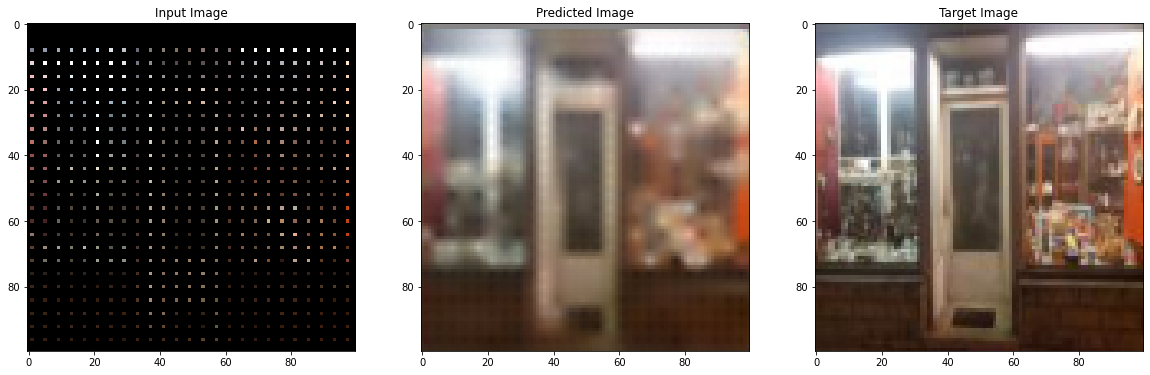

In [10]:
fig, axs = plt.subplots(1,3, figsize=(20,20))

axs[0].imshow(input_image)
axs[0].set_title("Input Image")

axs[1].imshow(pred_image)
axs[1].set_title("Predicted Image")

axs[2].imshow(target_image)
axs[2].set_title("Target Image")

plt.show()

<h4>Plotting Loss Histogram over all samples from training and validation set</h4>

Training Set:
min:  5.174756e-05
median:  0.0053185876
max:  0.046961006

------------------------------

Validation Set:
min:  0.00010213268
median:  0.0053123566
max:  0.07407329


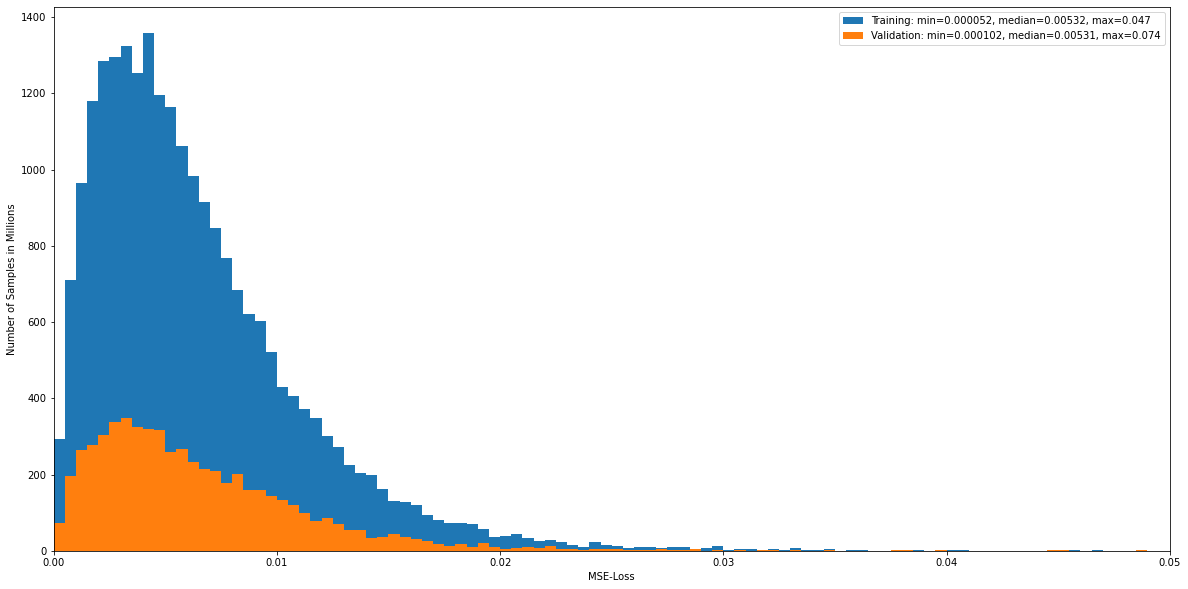

In [11]:
train_loss = train_dict["loss_list"]
val_loss = val_dict["loss_list"]

plt.figure(figsize=(20, 10))
#mini = np.min(np.sort(train_dict["CE_loss"]))
#mini_round = round(mini, 5)
#print(mini_round)
t = plt.hist(train_loss, bins=100, range=(0, 0.05), label="Training: min={:.6f}, median={:.6}, max={:.4}".format(np.min(np.sort(train_loss)), np.median(np.sort(train_loss)).round(5), np.max(np.sort(train_loss)).round(3)))
v = plt.hist(val_loss, bins=100, range=(0, 0.05), label="Validation: min={:.6f}, median={:.6}, max={:.4}".format(np.min(np.sort(val_loss)), np.median(np.sort(val_loss)).round(5), np.max(np.sort(val_loss)).round(3)))

plt.xlim([0, 0.05])
plt.xlabel("MSE-Loss")
plt.ylabel("Number of Samples in Millions")

plt.legend()

print("Training Set:")
print("min: ", np.min(np.sort(train_loss)))
print("median: ", np.median(np.sort(train_loss)))
print("max: ", np.max(np.sort(train_loss)))

print("\n------------------------------\n")

print("Validation Set:")
print("min: ", np.min(np.sort(val_loss)))
print("median: ", np.median(np.sort(val_loss)))
print("max: ", np.max(np.sort(val_loss)))

In [12]:
N = 100
highest_loss_indices = val_loss.argsort()[-N:]#[::-1]

middle = val_loss.shape[0]
middle_loss_indices = val_loss.argsort()[(middle//2)-(N//2):(middle//2)+(N//2)]

lowest_loss_indices = val_loss.argsort()[:N]#[::-1]

print("highest losses: ", val_loss[highest_loss_indices])

highest losses:  [0.02050032 0.02050396 0.02054768 0.02058695 0.02064174 0.02078789
 0.02097058 0.02102145 0.02103395 0.02105081 0.02111863 0.02114937
 0.02115598 0.02117803 0.02132099 0.02134959 0.02137781 0.02141465
 0.02151122 0.02152685 0.02153177 0.02154853 0.02163598 0.02166773
 0.02186551 0.02195749 0.02201233 0.02202081 0.02202572 0.02211991
 0.022139   0.02215597 0.02215902 0.02222616 0.02243339 0.02243353
 0.02247073 0.02249665 0.02254338 0.02265112 0.02271316 0.0227653
 0.0229877  0.02301896 0.02326071 0.0233482  0.02340153 0.02344139
 0.02360321 0.02367922 0.02376338 0.02413091 0.02418435 0.02421346
 0.0242643  0.02440183 0.02450713 0.02453655 0.02460239 0.02475418
 0.02479113 0.02505104 0.02509704 0.02522806 0.02528425 0.02592239
 0.02597255 0.0261828  0.02640058 0.02669976 0.02673395 0.02675804
 0.02704554 0.02710999 0.02724933 0.02749412 0.02788618 0.02826721
 0.02855506 0.0286466  0.02879494 0.02886976 0.0297027  0.02976232
 0.03058557 0.03069611 0.03092192 0.03169607 0

In [13]:
t_highest_loss_indices = train_loss.argsort()[-N:]#[::-1]

t_middle = train_loss.shape[0]
t_middle_loss_indices = train_loss.argsort()[(t_middle//2)-(N//2):(t_middle//2)+(N//2)]

t_lowest_loss_indices = train_loss.argsort()[:N]#[::-1]

print("highest losses: ", train_loss[t_highest_loss_indices])

highest losses:  [0.02694323 0.0269963  0.02707253 0.02714437 0.02722152 0.02729253
 0.02742528 0.02745456 0.02747321 0.02748234 0.0275163  0.0275336
 0.0275481  0.0275612  0.02766579 0.02770789 0.02775807 0.02783768
 0.02787809 0.02807335 0.02822149 0.02823901 0.02825134 0.02825829
 0.02829214 0.02833766 0.02838797 0.02843632 0.02863861 0.02872711
 0.02875774 0.02882025 0.02904972 0.02918559 0.0292808  0.02931158
 0.02931422 0.02942234 0.02943441 0.0294576  0.02951301 0.02953979
 0.02969084 0.02969187 0.02969391 0.02979394 0.02980295 0.02983373
 0.02987804 0.02988211 0.02991572 0.02993388 0.02998193 0.03012862
 0.03024019 0.03035594 0.03052857 0.03081015 0.03081645 0.03090947
 0.03100851 0.03137158 0.03142647 0.03149403 0.03160074 0.03167013
 0.03194626 0.03204789 0.03225787 0.03233244 0.03240303 0.03276013
 0.0330124  0.03302516 0.0331257  0.03315251 0.03319055 0.03338525
 0.03346752 0.03364406 0.03434588 0.03439785 0.03461764 0.03469086
 0.03473788 0.03494294 0.03555897 0.03556224 0

Text(0.5, 1.0, 'Target Image')

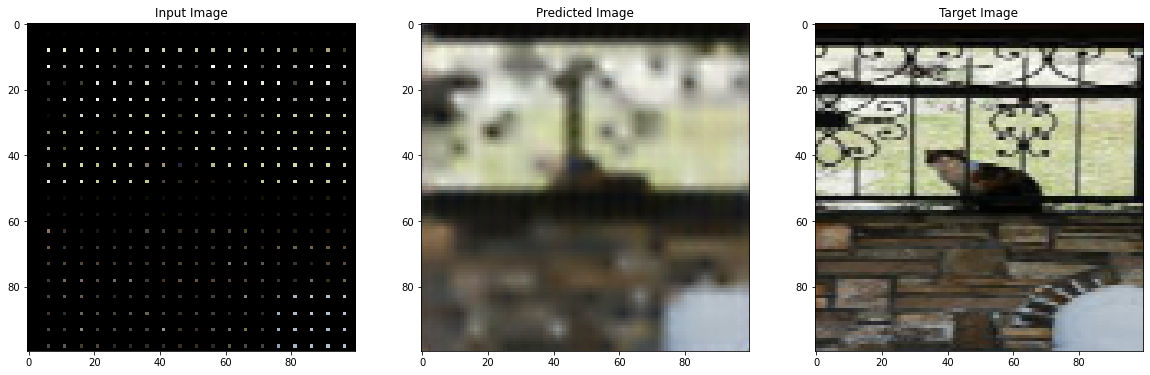

In [14]:
idx = 98
data_dict = val_dict
loss_idcs = highest_loss_indices

input_image = np.moveaxis(data_dict["input_images"][loss_idcs][idx], 0, -1)
pred_image = np.moveaxis(data_dict["pred_images"][loss_idcs][idx], 0, -1)
target_image = np.moveaxis(data_dict["target_images"][loss_idcs][idx], 0, -1)

fig, axs = plt.subplots(1,3, figsize=(20,20))

axs[0].imshow(input_image)
axs[0].set_title("Input Image")

axs[1].imshow(pred_image)
axs[1].set_title("Predicted Image")

axs[2].imshow(target_image)
axs[2].set_title("Target Image")

In [15]:

import os
from pickletools import optimize
import splitfolders
import json
import h5py

from utils.validate import validate_images
from dataset_generator import create_dataset
from models import Autoencoder, train_network, create_data_dict

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader

In [16]:
path_to_experiments = os.path.abspath(r"../../ImageInpaintingExperiments")
if not os.path.exists(path_to_experiments):
    os.makedirs(path_to_experiments)

experiment_id = "Submission_08"
path_to_current_experiment = os.path.join(path_to_experiments, experiment_id)
if not os.path.exists(path_to_current_experiment):
    os.makedirs(path_to_current_experiment)

config = {
    "Data": {
        "raw_img_dir": os.path.join(path_to_experiments, "training/"),
        "data_dir": os.path.join(path_to_current_experiment, "Data/"),
        "valid_img_folder": r"Valid_data",
        "log_file": "logfile.log",
        "formatter": "06d",
        "train_val_split_folder": r"Dataset",
        "seed": 1337,
        "train_val_split_ratio": (0.8, 0.2),
        "spacing_range": (2, 6),
        "offset_range": (1, 8)
    },
    "Model": {
        "lr": 5e-4,
        "path_to_model": os.path.join(path_to_current_experiment, "model.pth")
    },
    "Training": {
        "epochs": 200,
        "batch_size": 512
    }
}

FILTER_IMAGES = False
CREATE_DATASET = False
TRAIN_MODEL = False
LOG_MODEL = False
CREATE_DATA_DICTS = False

train_input_dir = os.path.join(os.path.join(config["Data"]["data_dir"], config["Data"]["train_val_split_folder"]), "train/")
val_input_dir = os.path.join(os.path.join(config["Data"]["data_dir"], config["Data"]["train_val_split_folder"]), "val/")
test_input_dir = os.path.join(path_to_experiments, "test/inputs.pkl")
path_to_train_data_dict = path_to_current_experiment + "/train_data_dict.hdf5"
path_to_val_data_dict = path_to_current_experiment + "/val_data_dict.hdf5"

if CREATE_DATASET == True:
    if FILTER_IMAGES == True:
        print("Filter images:")
        print("input dir: ", config["Data"]["raw_img_dir"])

        ## Check if images are in correct format etc. ##
        valid_img_count = validate_images(
            input_dir=config["Data"]["raw_img_dir"], 
            output_dir=os.path.join(config["Data"]["data_dir"], config["Data"]["valid_img_folder"]), 
            log_file=os.path.join(config["Data"]["data_dir"], config["Data"]["log_file"]), 
            formatter=config["Data"]["formatter"]
        )
        print(f"Number of valid images: {valid_img_count}")

    print("Create dataset:")

    ## Split data into train an validation set ##
    splitfolders.ratio(
        input=config["Data"]["data_dir"], 
        output=os.path.join(config["Data"]["data_dir"], config["Data"]["train_val_split_folder"]), 
        seed=config["Data"]["seed"], 
        ratio=config["Data"]["train_val_split_ratio"]
    )
    
    print("train_input_dir: ", train_input_dir)
    print("val_input_dir: ", val_input_dir)

    ## create datasets for training and validation ##
    train_dataset, val_dataset, test_dataset = create_dataset(
        input_dirs=(train_input_dir, val_input_dir, test_input_dir),
        spacing_range=config["Data"]["spacing_range"],
        offset_range=config["Data"]["offset_range"]
    )

    print(f"train_dataset length: {len(train_dataset)}")
    print(f"val_dataset length: {len(val_dataset)}")
    print(f"test_dataset length: {len(test_dataset)}")

    print("Saving datasets...")
    torch.save(train_dataset, os.path.join(path_to_current_experiment, "train_dataset.pt"))
    torch.save(val_dataset, os.path.join(path_to_current_experiment, "val_dataset.pt"))
    torch.save(test_dataset, os.path.join(path_to_current_experiment, "test_dataset.pt"))
    print("Successfully saved datasets!")
else:
    print("Loading dataset:")
    train_dataset = torch.load(os.path.join(path_to_current_experiment, "train_dataset.pt"))
    val_dataset = torch.load(os.path.join(path_to_current_experiment, "val_dataset.pt"))
    test_dataset = torch.load(os.path.join(path_to_current_experiment, "test_dataset.pt"))
    print(f"train_dataset length: {len(train_dataset)}")
    print(f"val_dataset length: {len(val_dataset)}")
    print(f"test_dataset length: {len(test_dataset)}")

train_dataloader = DataLoader(train_dataset, batch_size=config["Training"]["batch_size"], shuffle=True, drop_last=True)
val_dataloader = DataLoader(val_dataset, batch_size=config["Training"]["batch_size"], shuffle=False)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
#device = 'cpu'
print(f'Using {device} device')

Loading dataset:
train_dataset length: 23524
val_dataset length: 5882
test_dataset length: 8663
Using cuda device


In [17]:
f, i, k, s, o = val_dataset[:]

In [18]:
print(train_dataset.std)
print(train_dataset.mean)

[51.99612979 51.76043178 55.10665363]
[124.73771383 120.84927925 113.58349234]


In [19]:
idx = 10

image = i[idx]
image.shape

torch.Size([3, 100, 100])

In [20]:
print(image.mean())
print(torch.var(image)) 

tensor(0.4777)
tensor(0.0549)


In [21]:
gt = val_dataset.gt[idx]
gt.shape

AttributeError: 'ImageDataset' object has no attribute 'gt'

In [ ]:
print(gt.mean())
print(torch.var(gt)) 

NameError: name 'gt' is not defined

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
gt.dtype

NameError: name 'gt' is not defined

<h4>Normalizing / Denormalizing</h4>

NameError: name 'gt' is not defined

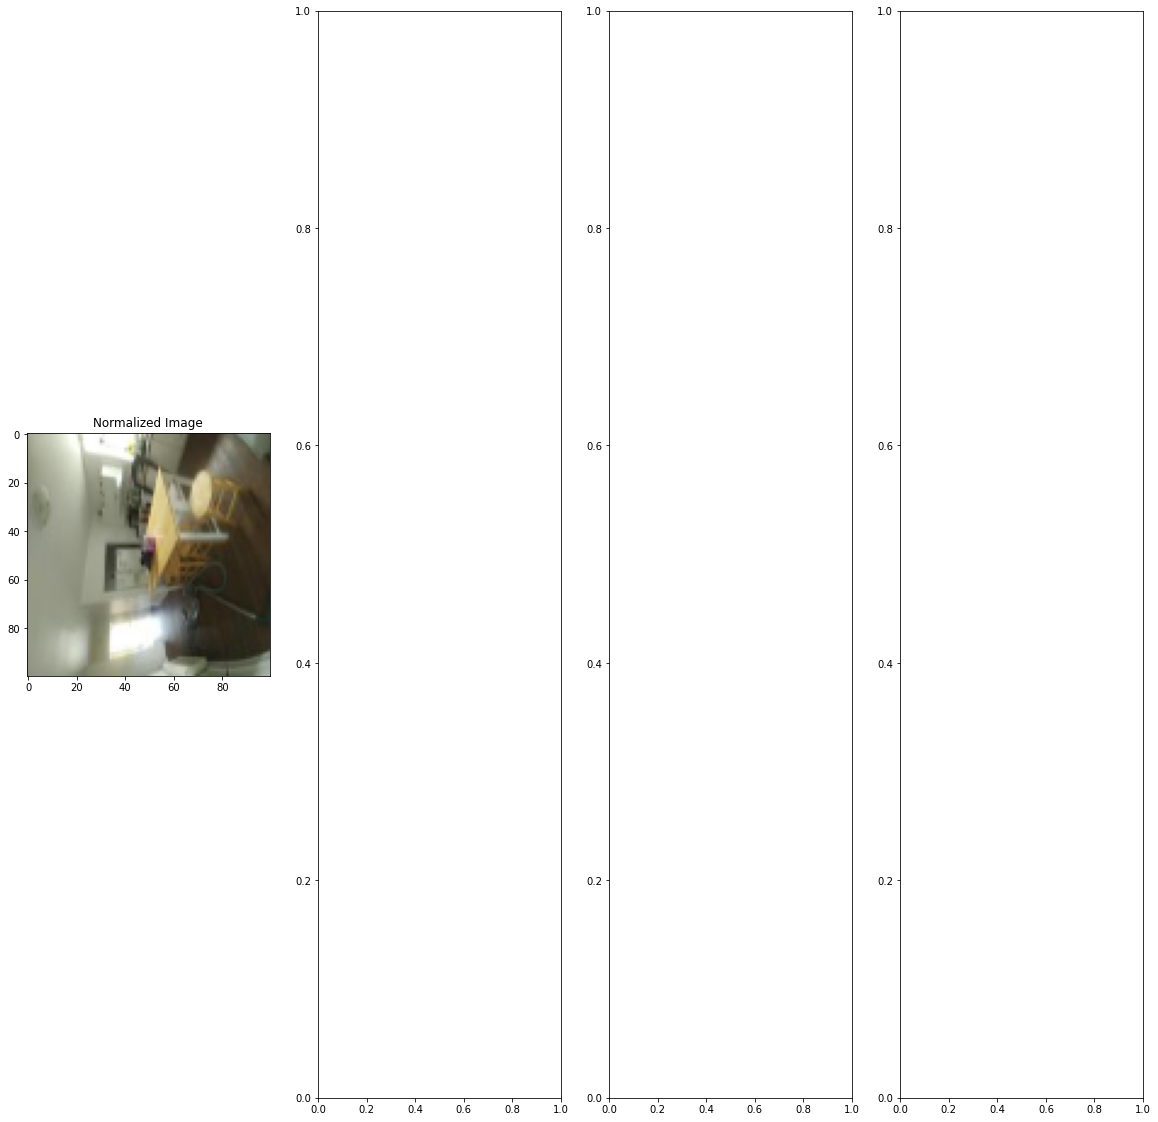

In [ ]:
fig, axs = plt.subplots(1,4, figsize=(20,20))

axs[0].imshow(torch.moveaxis(image, 0, -1))
axs[0].set_title("Normalized Image")

axs[1].imshow(torch.moveaxis(gt.long(), 0, -1))
axs[1].set_title("Ground Truth Image")

axs[2].imshow((torch.moveaxis(image, 0, -1)*255).long())
axs[2].set_title("Denormalized Image")

axs[3].imshow(torch.moveaxis(gt.long(), 0, -1)-(torch.moveaxis(image, 0, -1)*255).long())
axs[3].set_title("Denormalized Image")

plt.show()

In [ ]:
(torch.moveaxis(gt.long(), 0, -1)-(torch.moveaxis(image, 0, -1)*train_dataset.std+train_dataset.mean).long()).float().mean()

NameError: name 'gt' is not defined

<h4>Check target array</h4>

In [ ]:
target = val_dataset.targets[idx]

In [ ]:
print(target.shape)
print(target.min())
print(target.max())
print(target.mean())
print(torch.var(target))

torch.Size([29232])
tensor(0.0215)
tensor(1.)
tensor(0.4778)
tensor(0.0550)


In [ ]:
t = image[k[idx] == 0]

In [ ]:
print(t.shape)
print(t.min())
print(t.max())
print(t.mean())
print(torch.var(t))

torch.Size([29232])
tensor(0.0215)
tensor(1.)
tensor(0.4778)
tensor(0.0550)


In [ ]:
diff = t - target
print(diff.sum())

tensor(0.)


In [22]:
from models import Autoencoder, SimpleCNN, train_network, create_data_dict, create_test_predictions

In [23]:
model = SimpleCNN(6, 5, 64, 3)

n_hidden_layers:  5
n_kernels:  64


In [24]:
model.load_state_dict(torch.load(os.path.abspath(r"../../ImageInpaintingExperiments/Submission_08/model.pth")))

<All keys matched successfully>

In [25]:


device = "cpu"
predictions_list, image_list = create_test_predictions(
        model=model, 
        device=device,
        test_dataset=val_dataset
    )

100%|██████████| 5882/5882 [00:45<00:00, 128.86it/s]


In [26]:
pred_target = predictions_list[idx]
target = val_dataset.targets[idx]
pred_image = image_list[idx]
target_image = val_dataset.images[idx]

In [27]:
print(pred_target[:10])
im = val_dataset.images[idx]
denorm_im = (im*255).long()
k = val_dataset.known_pixels[idx]
target = denorm_im[k < 1]
print(target[:10])

[117 134 135 136 136 137 137 137 137 137]
tensor([160, 169, 174, 179, 181, 185, 189, 193, 197, 200])


In [30]:
maxi = pred_image.max()

In [31]:
maxi

265.76114

In [59]:
pred_image[maxi]

IndexError: index 8143 is out of bounds for axis 0 with size 3

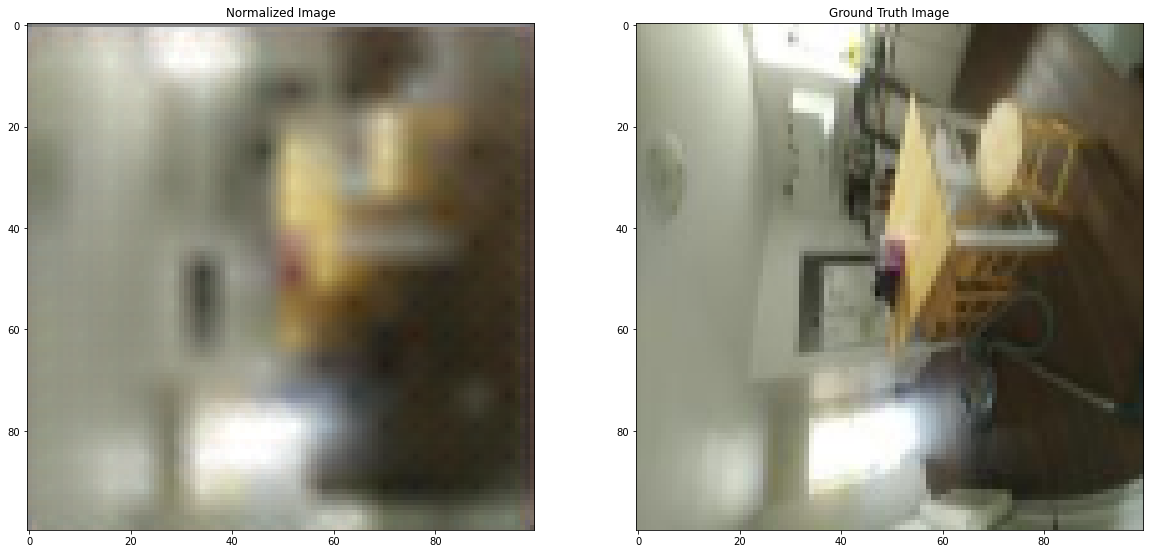

In [32]:
fig, axs = plt.subplots(1,2, figsize=(20,20))

axs[0].imshow(np.moveaxis(np.clip(pred_image, 0, 255).astype(np.uint8), 0, -1))
axs[0].set_title("Normalized Image")

axs[1].imshow(torch.moveaxis(target_image, 0, -1))
axs[1].set_title("Ground Truth Image")


plt.show()

In [90]:
idx = np.random.randint(0, 1000)
test_input, k, _, _ = test_dataset[idx]

In [91]:
model.eval()
with torch.no_grad():
    pred = model(torch.from_numpy(np.concatenate([test_input, k.copy()], axis=0)).float().to(device))

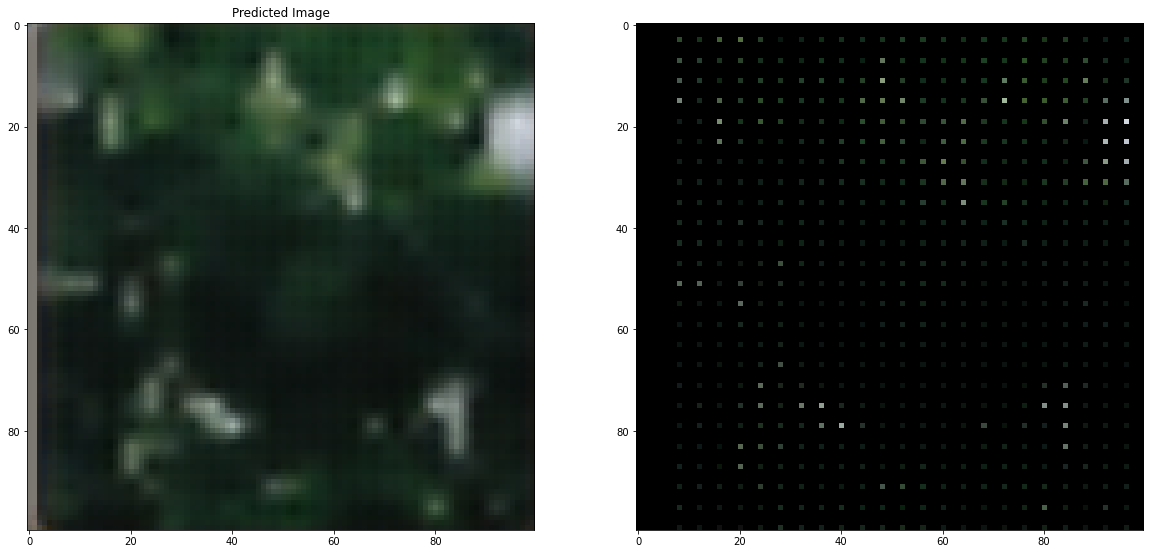

In [92]:
fig, axs = plt.subplots(1,2, figsize=(20,20))

axs[0].imshow(torch.moveaxis(pred.detach(), 0, -1))
axs[0].set_title("Predicted Image")

axs[1].imshow(torch.moveaxis(pred.detach()*k, 0, -1))
#axs[1].set_title("Ground Truth Image")

plt.show()